In [2]:
import pandas as pd

df=pd.read_csv("loan_approval_data.csv")
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [3]:
df.isnull().sum()
#df.describe()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
# beacause it is not contributing to output

df= df.drop(columns=["Applicant_ID"])
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [5]:
categorical_cols= df.select_dtypes(include=["object"]).columns   # mode
numerical_cols= df.select_dtypes(include=["number"]).columns    # mean strategy

In [6]:
categorical_cols
numerical_cols

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [7]:
# replacing empty numerical columns with mean and categorical empty columns values with mode 

from sklearn.impute import SimpleImputer

num_si= SimpleImputer(strategy='mean')
df[numerical_cols]= num_si.fit_transform(df[numerical_cols])
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [8]:
cat_si= SimpleImputer(strategy="most_frequent")
df[categorical_cols]= cat_si.fit_transform(df[categorical_cols])

In [29]:
#df.isnull().sum()               #no null values

In [9]:
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


EDA

Text(0.5, 1.0, 'Is Loan approved or Not?')

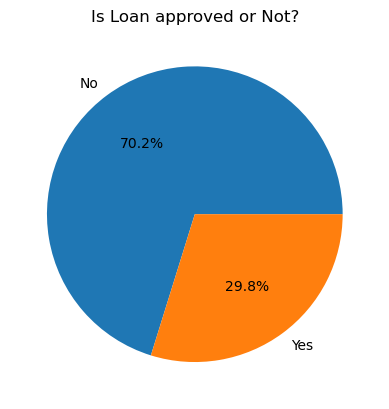

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

classes_count= df["Loan_Approved"].value_counts()
plt.pie(classes_count, autopct="%1.1f%%", labels=["No","Yes"])
plt.title("Is Loan approved or Not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

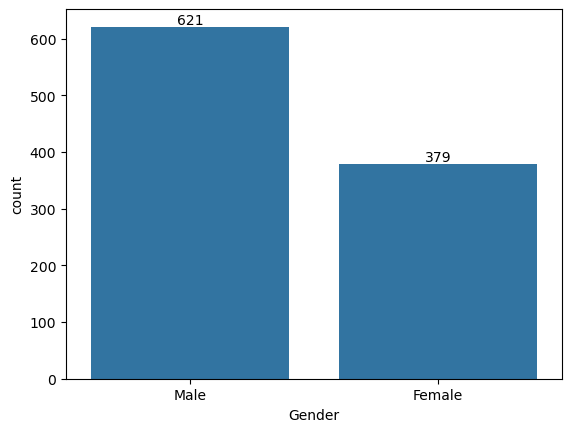

In [80]:
# analyze categories
import seaborn as sns

gender_cts= df["Gender"].value_counts()
ax= sns.barplot( gender_cts )
ax.bar_label( ax.containers[0] )

[Text(0, 0, '722'), Text(0, 0, '278')]

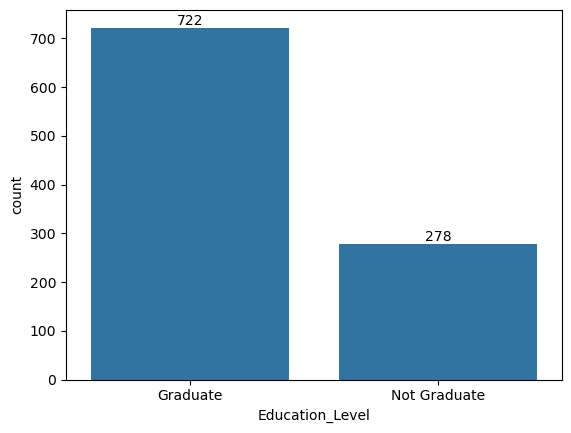

In [81]:
# analyze categories

edu_cts= df["Education_Level"].value_counts()
ax= sns.barplot(edu_cts)
ax.bar_label( ax.containers[0] )

<Axes: xlabel='Marital_Status', ylabel='count'>

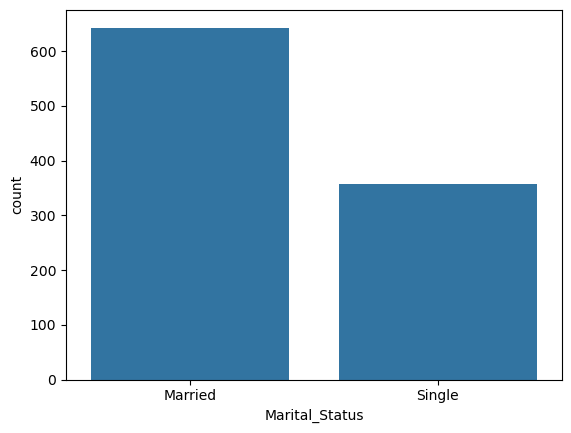

In [86]:
# analyze categories

mar_cts= df["Marital_Status"].value_counts()
sns.barplot( mar_cts )
#ax.bar_label( ax.containers[0] )

<Axes: xlabel='Applicant_Income', ylabel='Count'>

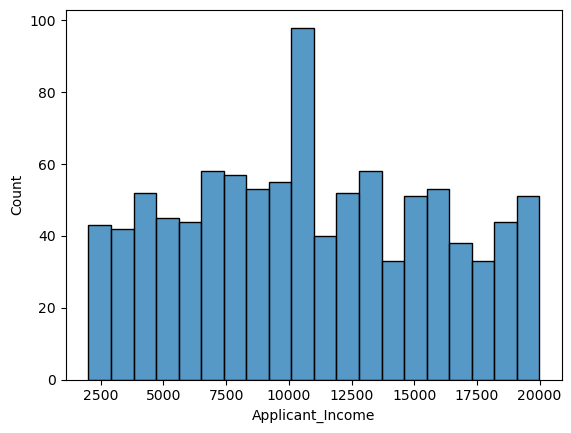

In [87]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

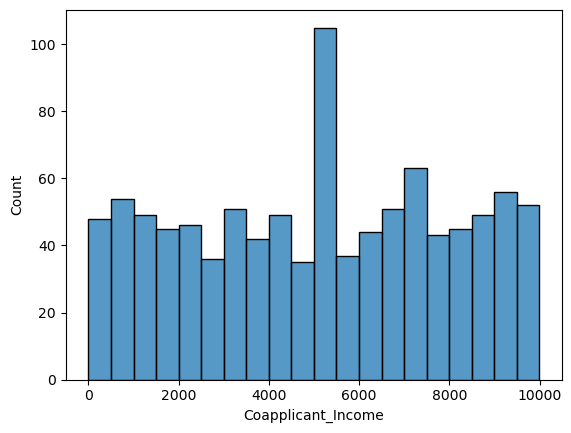

In [88]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)

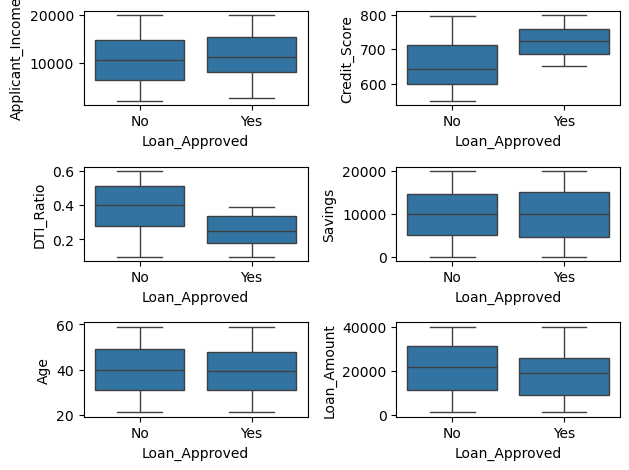

In [89]:
# outliers

fig, axes = plt.subplots(3,2)
sns.boxplot( ax=axes[0,0] , data=df, x="Loan_Approved", y="Applicant_Income" )
sns.boxplot( ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score" )
sns.boxplot( ax=axes[1,0], data=df, x="Loan_Approved", y="DTI_Ratio" )
sns.boxplot( ax=axes[1,1], data=df, x="Loan_Approved", y="Savings" )
sns.boxplot( ax=axes[2,0], data=df, x="Loan_Approved", y="Age" )
sns.boxplot( ax=axes[2,1], data=df, x="Loan_Approved", y="Loan_Amount" )
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

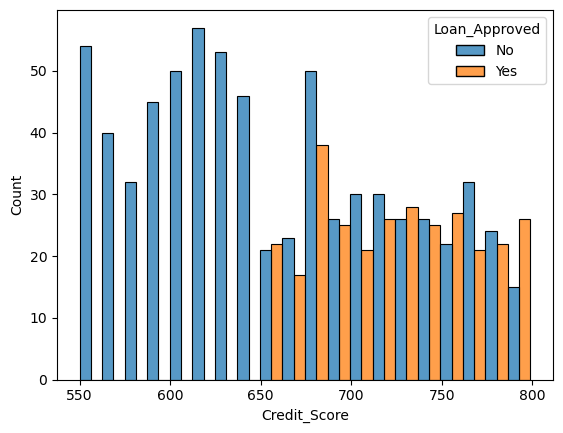

In [90]:
# Credit score with Loan Approved

sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"    # move them side by side
)


<Axes: xlabel='Applicant_Income', ylabel='Count'>

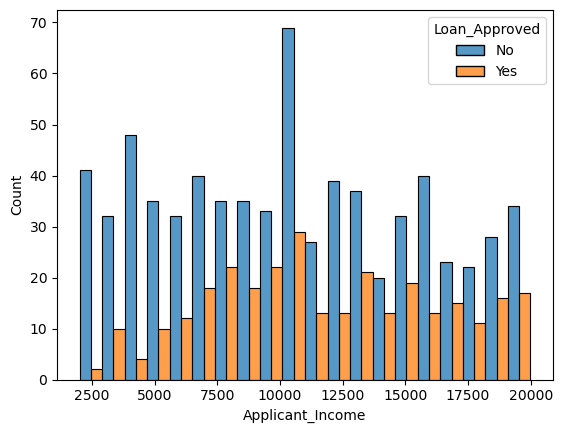

In [91]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [31]:
df["Employment_Status"].unique()

array(['Salaried', 'Self-employed', 'Contract', 'Unemployed'],
      dtype=object)

In [10]:
# LabelEncoder :- when you want to give preference to something eg( 0,1,2,3 )
# OneHotEncoder :- when you want to give equal preference    eg( 0,1 )

from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [11]:
# one hot encoding

cols=["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

from sklearn.preprocessing import OneHotEncoder

ohe= OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded= ohe.fit_transform(df[cols])
encoded         # in 2D array format

array([[0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(1000, 21))

In [12]:
import pandas as pd

encoded_df= pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df= pd.concat( [ df.drop(columns=cols) , encoded_df ], axis=1 )

In [13]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Gender_Female,Gender_Male,Employer_Category_Business,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

Correlation Heatmap

In [109]:
num_cols= df.select_dtypes(include="number")
corr_matrix= num_cols.corr()

In [111]:
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employment_Status_Contract         0.082910
Employer_Category_MNC              0.069049
Gender_Female                      0.054342
Loan_Purpose_Business              0.034767
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Business        -0.001472
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Property_Area_Rural               -0.017334
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                      

<Axes: >

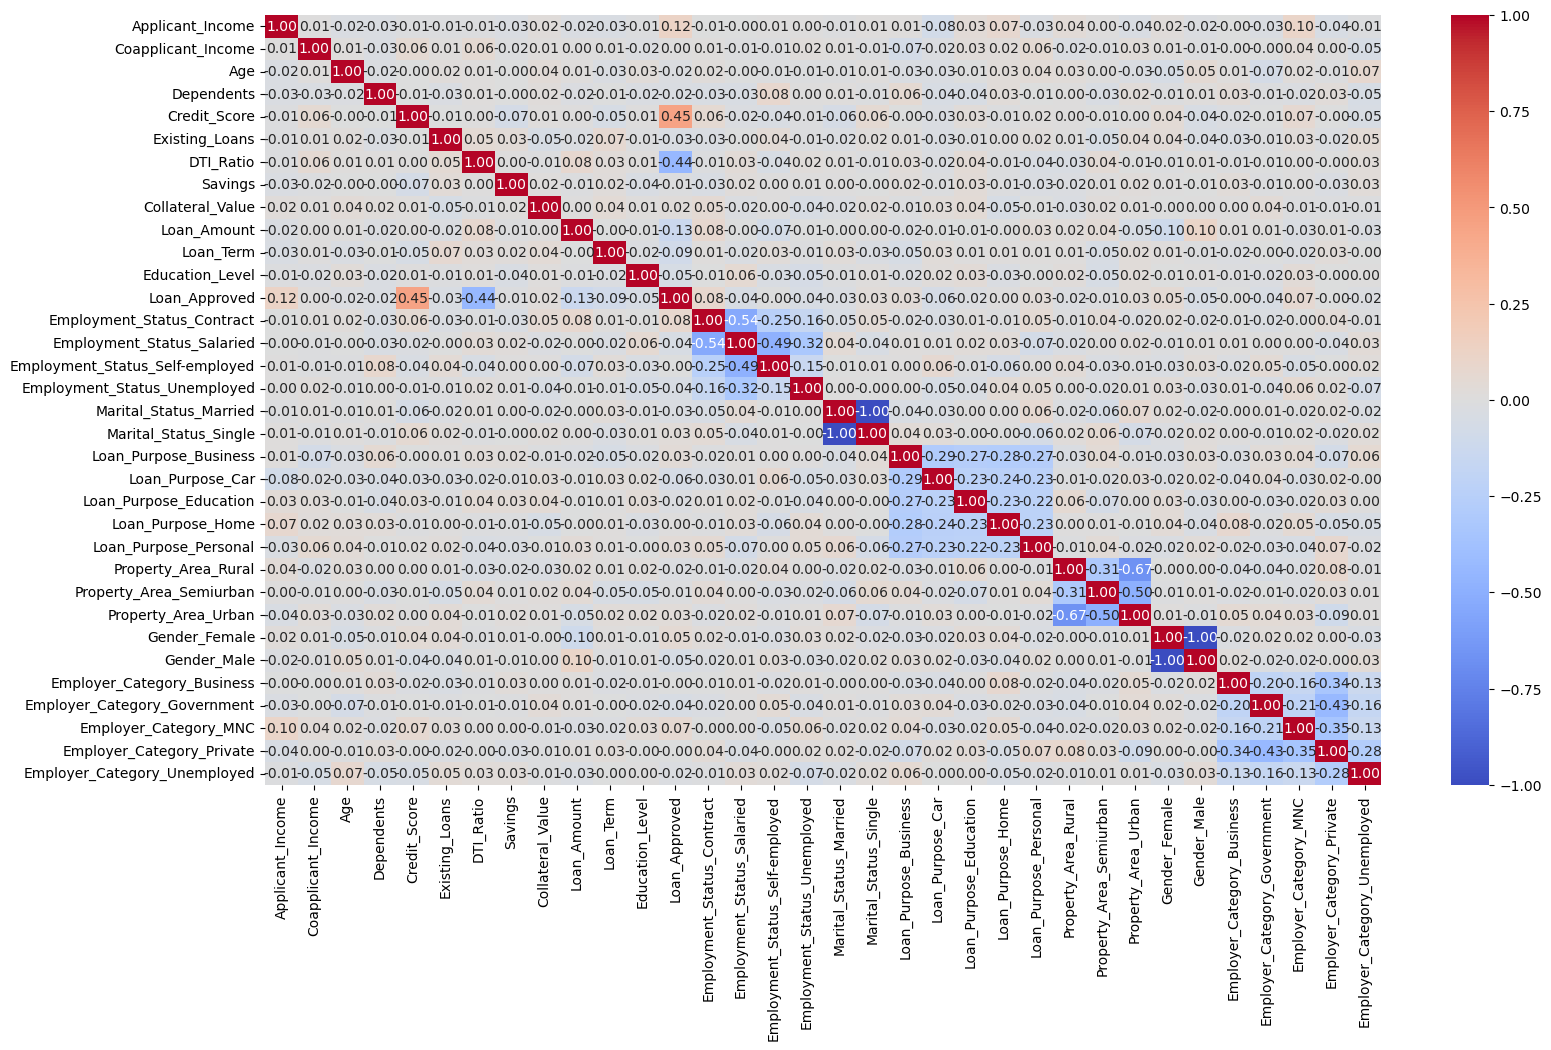

In [115]:
plt.figure(figsize=(18,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [45]:
#df["Employer_Category"].unique()

In [16]:
X= df.drop(columns=["Loan_Approved"])
y= df["Loan_Approved"]

In [17]:
# train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [18]:
# scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [19]:
# logistic regression model training

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model= LogisticRegression()

lr_model.fit(X_train_scaled, y_train)
y_pred= lr_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Logistic Regression
Accuracy: 0.865
Precision: 0.7833333333333333
Recall score: 0.7704918032786885
F1 score: 0.7768595041322314


In [117]:
# naive bayes

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)
y_pred= gnb.predict(X_test_scaled)
print("Naive Bayes")
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))      #
print("Recall score:", recall_score(y_test, y_pred))     #
print("F1 score:", f1_score(y_test, y_pred))

Naive Bayes
Accuracy: 0.85
Precision: 0.7719298245614035
Recall score: 0.7213114754098361
F1 score: 0.7457627118644068


In [118]:
# knn         # knn is not suitable for more featrues beacuse the distance increases

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn= KNeighborsClassifier()
param_grid= {"n_neighbors": [3,5,7,9]}

classifierCV= GridSearchCV(
    knn,
    param_grid,
    cv=5,  # no. of folds
)

classifierCV.fit(X_train_scaled, y_train)
y_pred= classifierCV.predict(X_test_scaled)
print("kNN")
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print(classifierCV.best_params_) 

kNN
Accuracy: 0.755
Precision: 0.6666666666666666
Recall score: 0.39344262295081966
F1 score: 0.4948453608247423
{'n_neighbors': 9}


Feature Engineering

In [25]:
# Add or Transform features
import numpy as np

df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"] = df["Credit_Score"]**2

#df["Applicant_Income_log"]= np.log1p(df["Applicant_Income"])  # for skewed data

X= df.drop(columns=["Loan_Approved", "DTI_Ratio", "Credit_Score"])
y= df["Loan_Approved"]

# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [26]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Gender_Female,Gender_Male,Employer_Category_Business,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.2809,405769.0,9.786729
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0900,385641.0,7.958926
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0400,454276.0,8.908018
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0961,335241.0,9.544309
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0841,519841.0,9.494391


In [27]:
# logistic regression model training

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model= LogisticRegression()

lr_model.fit(X_train_scaled, y_train)
y_pred= lr_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Logistic Regression
Accuracy: 0.88
Precision: 0.7846153846153846
Recall score: 0.8360655737704918
F1 score: 0.8095238095238095


In [28]:
# naive bayes

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)
y_pred= gnb.predict(X_test_scaled)
print("Naive Bayes")
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))      #
print("Recall score:", recall_score(y_test, y_pred))     #
print("F1 score:", f1_score(y_test, y_pred))

Naive Bayes
Accuracy: 0.85
Precision: 0.7719298245614035
Recall score: 0.7213114754098361
F1 score: 0.7457627118644068


In [29]:
# knn         # knn is not suitable for more featrues beacuse the distance increases

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn= KNeighborsClassifier()
param_grid= {"n_neighbors": [3,5,7,9]}

classifierCV= GridSearchCV(
    knn,
    param_grid,
    cv=5,  # no. of folds
)

classifierCV.fit(X_train_scaled, y_train)
y_pred= classifierCV.predict(X_test_scaled)
print("kNN")
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall score:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print(classifierCV.best_params_)

kNN
Accuracy: 0.73
Precision: 0.5614035087719298
Recall score: 0.5245901639344263
F1 score: 0.5423728813559322
{'n_neighbors': 3}
